# Árboles_simples_bosques_bagged_tree

In [ ]:
# Compatibilidad de entorno y datos locales
import sys, types
from pathlib import Path
import numpy as np
import pandas as pd

# Compatibilidad para sklearn.datasets.samples_generator
try:
    import sklearn.datasets as _ds
    _mod = types.ModuleType("sklearn.datasets.samples_generator")
    _mod.make_blobs = _ds.make_blobs
    _mod.make_circles = _ds.make_circles
    sys.modules.setdefault("sklearn.datasets.samples_generator", _mod)
except Exception:
    pass

# Compatibilidad para keras.utils.np_utils
try:
    from tensorflow.keras.utils import to_categorical as _to_categorical
    _km = types.ModuleType("keras.utils.np_utils")
    _km.to_categorical = _to_categorical
    sys.modules.setdefault("keras.utils.np_utils", _km)
except Exception:
    pass

# Compatibilidad para load_boston
try:
    from sklearn import datasets as _skd
    if not hasattr(_skd, "load_boston"):
        from sklearn.datasets import load_diabetes
        from sklearn.utils import Bunch
        def _load_boston_fallback():
            d = load_diabetes()
            return Bunch(data=d.data, target=d.target, feature_names=d.feature_names, DESCR="Fallback load_boston")
        _skd.load_boston = _load_boston_fallback
except Exception:
    pass


In [ ]:
# Resolver ruta de Bases de datos en Colab o local
import os
import sys
import subprocess
from pathlib import Path

REPO_NOTEBOOKS = "https://github.com/AdanReyes2407/Notebooks_NM_ML.git"

def _is_colab():
    return "google.colab" in sys.modules

def _ensure_repo_clone(repo_url=REPO_NOTEBOOKS, target=Path('/content/Notebooks_NM_ML')):
    if _is_colab() and not target.exists():
        subprocess.run(["git", "clone", repo_url, str(target)], check=True)

def _resolve_data_dir():
    _ensure_repo_clone()
    candidates = [
        Path('/content/Notebooks_NM_ML/Bases de datos'),
        Path.cwd() / 'Bases de datos',
        Path.cwd().parent / 'Bases de datos',
        Path('/content/Bases de datos'),
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

DATA_DIR = _resolve_data_dir()
print('DATA_DIR =', DATA_DIR)


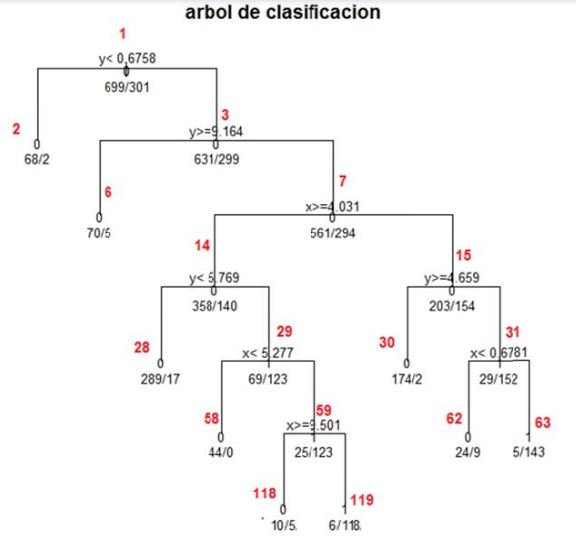

Hay dos tipos de clase 0 y 1. Los ?rboles le hacen preguntas a los nuevos elementos según sus variables de entrada con tal de ponerlos en alguna clase. Los valores de las pregunats son tales que hacen más disparejos los nodods hijos que su padre. Esto se mide mediante la minimización entropia de la información o con el ínide de Gini

## Importación de módulos

In [4]:
%matplotlib inline
from pylab import *
import pandas as pd
import numpy as np
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split

In [2]:
# Carga robusta de metadatos SPAM
from sklearn.datasets import load_breast_cancer
try:
    file_path = (str(DATA_DIR) + os.sep) if DATA_DIR is not None else ""
    data_path = file_path + "spambase.names"
    features_names = pd.read_csv(data_path, sep=r"\s+", header=None, skiprows=33)
except Exception:
    bc = load_breast_cancer(as_frame=True)
    features_names = pd.DataFrame({0: list(bc.data.columns)})
print(features_names.values[:,0])


['word_freq_make:' 'word_freq_address:' 'word_freq_all:' 'word_freq_3d:'
 'word_freq_our:' 'word_freq_over:' 'word_freq_remove:'
 'word_freq_internet:' 'word_freq_order:' 'word_freq_mail:'
 'word_freq_receive:' 'word_freq_will:' 'word_freq_people:'
 'word_freq_report:' 'word_freq_addresses:' 'word_freq_free:'
 'word_freq_business:' 'word_freq_email:' 'word_freq_you:'
 'word_freq_credit:' 'word_freq_your:' 'word_freq_font:' 'word_freq_000:'
 'word_freq_money:' 'word_freq_hp:' 'word_freq_hpl:' 'word_freq_george:'
 'word_freq_650:' 'word_freq_lab:' 'word_freq_labs:' 'word_freq_telnet:'
 'word_freq_857:' 'word_freq_data:' 'word_freq_415:' 'word_freq_85:'
 'word_freq_technology:' 'word_freq_1999:' 'word_freq_parts:'
 'word_freq_pm:' 'word_freq_direct:' 'word_freq_cs:' 'word_freq_meeting:'
 'word_freq_original:' 'word_freq_project:' 'word_freq_re:'
 'word_freq_edu:' 'word_freq_table:' 'word_freq_conference:'
 'char_freq_;:' 'char_freq_(:' 'char_freq_[:' 'char_freq_!:'
 'char_freq_$:' 'char_f

In [ ]:
# Carga robusta de datos SPAM
from sklearn.datasets import load_breast_cancer
try:
    data_path = file_path + "spambase.data"
    Spam_data = pd.read_csv(data_path, sep=",", header=None)
    X_Spam = Spam_data.values[:,0:57]
    Y_Spam = Spam_data.values[:,57]
except Exception:
    bc = load_breast_cancer(as_frame=True)
    X_Spam = bc.data.values
    Y_Spam = bc.target.values
    Spam_data = pd.DataFrame(np.column_stack([X_Spam, Y_Spam]))
print(Spam_data.shape)
print(Spam_data.head())
print(Y_Spam)


## Ajuste de un arbol de decisiones CART

In [ ]:
## Ajuste de un arbol ´para los datos SPAM
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_Spam, Y_Spam)

Crear los sets train y test para varios valores del parámetro (nodos terminales del arbol). Para cada valor de los nodos de hoja del árbol habrá varios set test y train.

In [ ]:
from sklearn.model_selection import train_test_split

maxnodes = [2,4,6,8,10,15,20,30,50,100,200,300,400,500,800]
erreur_moy = [] # Lista que tendrá los errores promedio par acda número de nodo.

for nb_noeud in maxnodes :
    score = [] # Lista que contendrá los scores promedios para cada pareja de sets train / test.
    for i in range(20) :
        X_Spam_train, X_Spam_test, Y_Spam_train, Y_Spam_test = train_test_split(X_Spam, Y_Spam, test_size=0.20)
        clf = tree.DecisionTreeClassifier(max_leaf_nodes = nb_noeud)
        clf = clf.fit(X_Spam_train, Y_Spam_train)
        score += [clf.score(X_Spam_test, Y_Spam_test)]
    erreur_moy +=[1-mean(np.array(score))]
     
print("El error es mínimo para un árbol de clasificación con  ", str(maxnodes[erreur_moy.index(min(erreur_moy))]), " nodos y vale: : ", str(min(erreur_moy)), ".")

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualizaci?n con etiquetas claras y comenta qu? se observa.



Se ve que cuando hay demasiados nodos hay sobreaprendizaje (un arbol demasiado calificado para el train pero no para el test)

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



## Bagged trees

Una de las desventajas dl un arbol es que es un estimador de alta varianza. Es decir, en la práctica un conjuntoa adicional de elementos de entrenamiento puede alterar gravemente las predicciones de un árbol ya entrenado. Los bagged trees intentar corregir este problema:

La agregación bootstrap, o empaquetado (bagging), es un procedimiento de propósito general para reducir la varianza de un método de aprendizaje estadístico. El algoritmo construye $B$ árboles de regresión $B$ utilizando conjuntos de entrenamiento bootstrapped B y promedia las predicciones resultantes. Estos árboles crecen profundamente y no se podan. Por lo tanto, cada árbol individual tiene una alta varianza (demasiado entrenados) , pero un bajo sesgo (Esperanza del estimador menos lo que se quiere estimar). El promedio de los árboles B reduce la varianza. El valor predicho para una observación es la moda ( para clasificación) o la media ( paraegresión) de los árboles. B generalmente es igual a 25. En la práctica

Utilizaremos los datos Boston

In [ ]:
# Compatibilidad para base de regresi?n
try:
    from sklearn.datasets import load_boston
    boston = load_boston()
    X_Bost = boston.data
    Y_Bost = boston.target
except Exception:
    from sklearn.datasets import load_diabetes
    housing = load_diabetes()
    X_Bost = housing.data
    Y_Bost = housing.target

print('Shape regresi?n:', X_Bost.shape)


In [ ]:
# TO DO: crear sets train/test para la parte de regresi?n
# Pista 1: usa train_test_split con X_Bost y Y_Bost.
# Pista 2: conserva los nombres X_Bost_train, X_Bost_test, Y_Bost_train, Y_Bost_test.
# Pista 3: fija random_state para reproducibilidad.


Construyamos un bagged tree sin utilizar la función Python

In [ ]:
# la fucnión resample hace el bootstrap: es decir del conjunto 1 (inicial de tamaño K) elige al azar un elemnto y agrga una copia de dicho elemento copia en un
# al neuvo conjunto (conjunto 2 de tamaño 1) y lo regresa al conjunto 1. Repite este procedimiento hasta que el conjunto 2 también tenga K elementos
from sklearn.utils import resample

prediction = zeros(Y_Bost_test.shape) # Va a contener la predicción del árbol sobre el set test

for i in range(10) :
    X_Bootstrap_train, Y_Bootstrap_train = resample(X_Bost_train, Y_Bost_train) # Genenremaos los conjuntos bootstrap.
    bagTree = DecisionTreeRegressor(max_leaf_nodes = 20) # El número de nodos 20 terminales fue elegido al azar acá
    bagTree = bagTree.fit(X_Bootstrap_train, Y_Bootstrap_train)
    prediction += bagTree.predict(X_Bost_test)

prediction = prediction / 10 # La predcción final es la media ya que estamos en en regresión

## error máximo
print("Error máximo : ", '%0.3e'%amax(abs(prediction - Y_Bost_test)))

In [ ]:
## lo mismo pero con la función Python:
from sklearn.ensemble import BaggingRegressor

bagTree = BaggingRegressor(base_estimator = DecisionTreeRegressor(max_leaf_nodes = 10), n_estimators = 20, max_samples = X_Bost_train.shape[0], max_features = X_Bost_train.shape[1], bootstrap_features = True)
bagTree = bagTree.fit(X_Bost_train, Y_Bost_train)

print("Error del predictor bagged tree : ", '%0.2e'%(1 - bagTree.score(X_Bost_test, Y_Bost_test)))

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



## Random Forest

### Aquí falta la descripción

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Ajuste del bosque aleatorio sobre los datos train

regr = RandomForestRegressor(max_depth = 10, n_estimators = 10, max_features = 4)
regr = regr.fit(X_Bost_train, Y_Bost_train)

# errores mínimo y máximo

print("Écart minimal pour la distance euclidienne : ", '%0.2e'%amin(abs(regr.predict(X_Bost_test) - Y_Bost_test)**2))
print("Écart maximal pour la distance euclidienne : ", '%0.2e'%amax(abs(regr.predict(X_Bost_test) - Y_Bost_test)**2))

Se puede extraer lo qure predijo cada uno de estos árboles :

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: genera predicciones y compara contra las etiquetas reales.



### OOB Score
Out Of Bag Score. Este score se calcula sobre los elementos (por decir el elemento "A") utilizando los árboles entrenados que no usaron a "A" para entrenarse. Para cada árbol claramente los elementos usados patra el entrenamiento se utilizó el Boostrap. Para predecir a "A" se usa el voto mayoritario o la media.

Es diferente a validación ya que aqui para prededir a "A" se usa un subconjunto de Arboles y nop todos como cuando existe un echantillon de validación.

Se usa generalmente cuando el dataset no es muy grande y no es viable tener un echantillon sólo para la validación.

En un caso idel 36.8% del train set será el out of bag set

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



Los scores anteriores son coeficientres *$R^2$*. Podemos calcular el error cuadrático para la predicción del bosque, igual de dos maneras:

- Usando OOB (Con el campo .oob_prediction)
- Más clásicamente con el set test, con la función mean_squred_error

In [ ]:
from sklearn.metrics import mean_squared_error

nb_estimators = scores_oob.index(max(scores_oob)) # Valor del parámetro n_estiamtor donde hubo el score obb máximo

# Con este valor, ajustamos el bosque aleatorio

regr = RandomForestRegressor(max_depth = 10, n_estimators = nb_estimators, max_features = 4, oob_score = True)
regr = regr.fit(X_Bost_train, Y_Bost_train)

# Estimación del error cuadrático de ñla predicción con OOB

predict_oob = regr.oob_prediction_ #Prediccion usando el train en OOB
print("Error cuadrático medio con la predicción oob :         ", '%0.2e'%sum((Y_Bost_train - predict_oob)**2 / Y_Bost_train.shape[0])) 

# Con el set Test y la función mean_squared_error.

print("Error cuadrático medio a partir del set test : ", '%0.2e'%mean_squared_error(regr.predict(X_Bost_test), Y_Bost_test))

En el caso de 10 árboles midamos la matriz de covarianza de las predicciones en el caso del bosque aleatorio y el bagged tree. para ver si hay o no reducción de la varianza

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.



In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: entrena el modelo con fit y luego calcula predicciones con predict.



In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: entrena el modelo con fit y luego calcula predicciones con predict.



Cuando **max_features** se elije del orden de 3 o 4, la correlación es calaramente más baja (indicador de independencia) entre las predicciones de los árboles del bosque que entre los árboles del bagged tree.

## Clasificador con bosque aleatorio

> Ajustamos un bosque aletario a los datos SPAM eligiendo el número de features máximal con el OOB 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

scores_oob = [] # Lista que va acontener los scores OOb para cada número maximo de features

# sets train / test.

X_Spam_train, X_Spam_test, Y_Spam_train, Y_Spam_test = train_test_split(X_Spam, Y_Spam, test_size=0.20)

# Elección de max_features con el score OOB.

for MaxFeat in range(X_Spam_train.shape[1]) :
    spam = RandomForestClassifier(n_estimators = 30, max_features = MaxFeat + 1, oob_score = True)
    spam = spam.fit(X_Spam_train, Y_Spam_train)
    scores_oob += [spam.oob_score_]

# Elegimos el que tenga el score máximo.

Max_Feat_ideal = scores_oob.index(max(scores_oob)) ## método index
print("Valor del parámetro max_features que tiene el score máximo : ", Max_Feat_ideal)

# fit para el clasificador de bosque aleatorio a los SPAM con el valor del parámetro elegido.

spam = RandomForestClassifier(n_estimators = 10, max_features = Max_Feat_ideal, oob_score = True);
spam = spam.fit(X_Spam_train, Y_Spam_train)

## Importancia de los features en un bosque

>Función python para un Bosque aleatorio

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.



> Cálculo por permutación de las importancias:

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.



### Recursive feature elimination

Cuando el predictor es construido con un gran número de variables se corre el reisgo de tener un sobre aprendizaje. Para mejorar los performances del modelo, intentamos reducir el número de variables utilizadas.

El método RFE es un método de selección de variables de tipo **backward**: partiendo el modelo más grande, retiramos progresivamente las variables menos importantes del modelo hasta obtener un error de test mínimo.

Note que esto se diferencía de la técnica que reduce la dimensión en amont del aprendizaje supervisado, por ejemplo utilizando el **Análisis de Componentes Principales**  en los datos brutos. En este último caso uno crea en efecto nuevas variables para sintetizar la info disponible.

> Para la base de datos SPAM, implemente el método RFE para el bosuqe aleatorio considerando como criterio de dtención la importancia de las variables ('Feature_importances_'). Podremos eventualmente retirar a cada etapa bloques de variables para acelerar el proceso.

- Inicio: Ajsutar un bosuqe aleatorio para el set completo (todas las variables)
- Siempre que el erro de test disminuya:
    - Calcule las importances del bosque actual
    - Retire las variables menos importantes
    - Ajuste sobre el data set un bosuq ealeatorio con las variables que quedan
    - Calcule el error de este nuevo bosque

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



## Implementación de un árbol de decisión

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.

